# FIE463 - Individual Assignment

## Optimal savings and portfolio choice

In [1]:
# Preparations
# Modules
import numpy as np
import matplotlib.pyplot as plt

# Define default parameters
beta = .9                               # Discount factor
gamma = 4                               # Absolute risk aversion
sigma_sq = .16**2                       # Variance of risky return shock
mu = .04                                # Expected excess return
w = 1                                   # Initial wealth
rf = 1                                  # Risk-free gross return

sigma = np.sqrt(sigma_sq)               # Sigma from root of sigma_sq (Variance)

# Distribution for risky return
probs = np.array((1/6, 2/3, 1/6))          # Probabilities of eta
etas = np.array((-3**.5, 0, 3**.5))      # Values of eta (shock representing uncertainty)

exp_eta = etas @ probs

### Task 1

In [2]:
# Verify that discretized risky return approximates the true mean and variance of the underlying normal distribution well
R = rf + mu + sigma * etas               # Risky return (vector)
er = rf + mu + sigma * exp_eta          # Expected gross risky return

var = probs @ (R - er)**2                 # Variance of the risky return
std = np.sqrt(var)                       # Standard deviation of the risky return

eR_prem = er - rf                       # Expected risk premium
sharpe = eR_prem / std                    # Sharpe-ratio

# Comparisons
print(f'True mu: {mu} vs Calculated: {eR_prem:.2f}')
print(f'True variance: {var} vs Calculated: {std}')

True mu: 0.04 vs Calculated: 0.04
True variance: 0.0256 vs Calculated: 0.16


Values of expected excess return and variance for the discretized risky return are equal to those of the given parameters. The discretized risky return approximates the true mean and variance of the underlying normal distribution well.

### Task 2

In [3]:
def util(c, gamma):
    '''
    Return the flow utility of consumption for a given risk aversion
    '''
    u = -np.exp(-gamma * c)

    return u

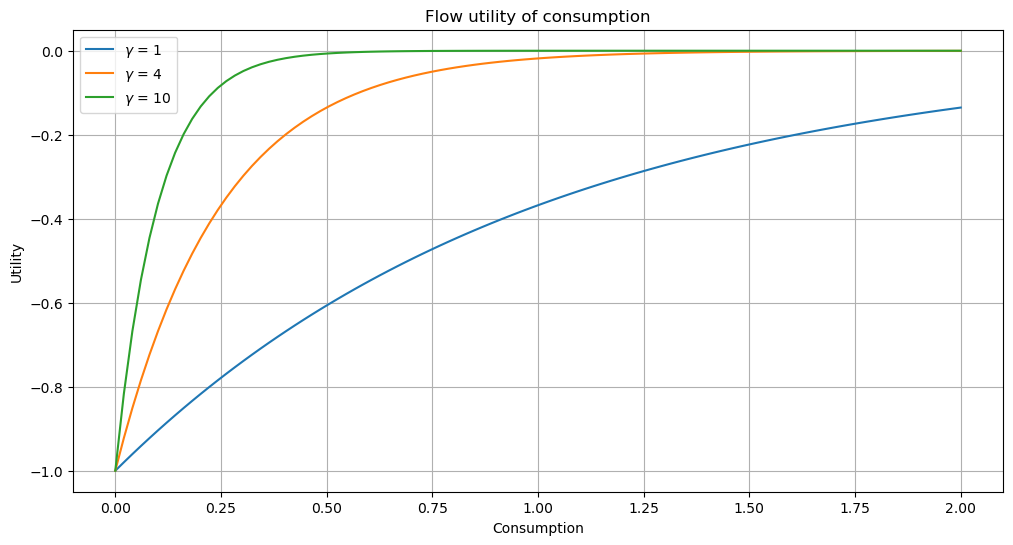

In [4]:
# Intialize parameters
c = np.linspace(0, 2, 100)
gammas = np.array((1, 4, 10))

# Intialize plot
plt.figure(figsize=(12,6))
plt.title('Flow utility of consumption')
plt.xlabel('Consumption')
plt.ylabel('Utility')
plt.grid()

# Loop over array of gammas to plot three separate curves
for g in gammas:
    u = util(c, g)
    plt.plot(c, u, label=fr'$\gamma$ = {g}')


# Display plot
_ = plt.legend()

### Task 3

In [ ]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    r = rf + mu + sigma * etas
    S, A, R = np.meshgrid(s, alpha, r, indexing='ij')
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - S

    # Period 1 utility
    u1 = util(c1, gamma)
    
    # Risky returns
    R = rf + mu + sigma * etas
    
    # Period 2 consumption
    c2 = R * A * S + rf * (1 - A) * S
    
    # Period 2 utilities (vector)
    u2 = util(c2, gamma)
    
    # Period 2 expected utility
    eu2 = np.sum(u2 * probs, axis=-1)
    
    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

### Task 4

ValueError: Valid values for `indexing` are 'xy' and 'ij'.

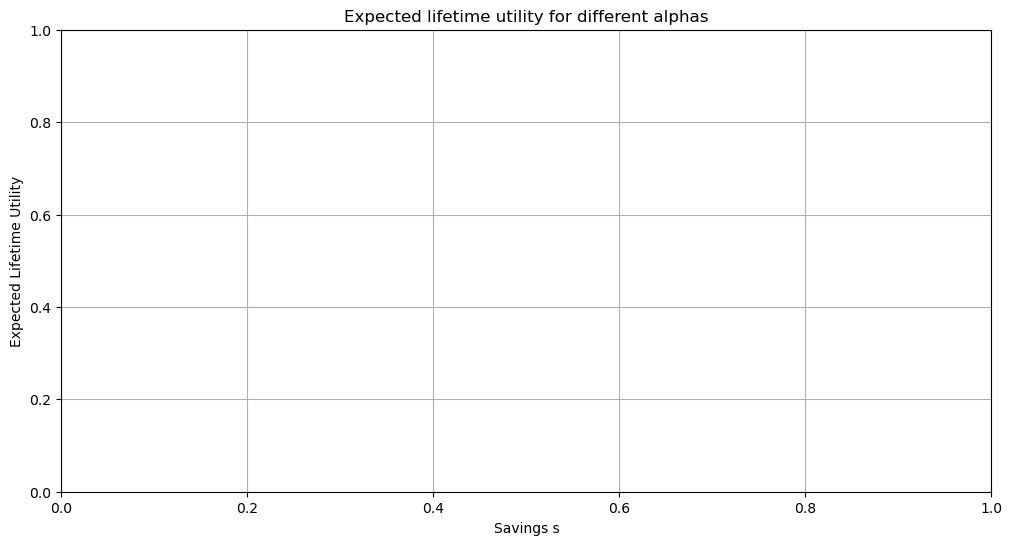

In [34]:
# Initialize parameters s and alpha
alphas = np.array((0, .5, 1))
s = np.linspace(.1, w - .1, 200)

# Initialize plot
plt.figure(figsize=(12,6))
plt.title('Expected lifetime utility for different alphas')
plt.xlabel('Savings s')
plt.ylabel('Expected Lifetime Utility')
plt.xlim((0,1))
plt.grid()

# Loop over alphas to plot
for a in alphas:
    eu_life = expected_util(s=s, alpha=a)
    plt.plot(s, eu_life.flatten(), label=fr'$\alpha$ = {a}')

_ = plt.legend()

The graph indicates that the optimal allocation of consumption between the two periods is about equal, regardless of the level of alpha. The three graphs being almost exactly equal should not be surprising, as the risk-aversion parameter is quite low at this moment.

### Task 5

In [26]:
def find_optimum(beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Find the optimal savings level and risky share to maximize expected utility
    '''
    # Initialize s and alpha as linear spaces (expected_util() handles array-dimensions)
    s = np.linspace(10**-6, w - 10**-6, 1_000)
    alpha = np.linspace(0, 1, 1_000)

    # Calculate expected lifetime utility for all combinations
    eu_life = expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs)

    # Find flat index of maximum
    idx_max = np.argmax(eu_life)

    # Convert flat index to (i_s, i_alpha)
    i_s, i_alpha = np.unravel_index(idx_max, eu_life.shape)

    # Optimal choices
    s_opt = s[i_s]
    a_opt = alpha[i_alpha]
    U_max = eu_life[i_s, i_alpha]

    return s_opt, a_opt, U_max

In [ ]:
find_optimum()

(np.float64(0.4824825175175174),
 np.float64(0.8098098098098098),
 np.float64(-0.25279977091370276))

In [28]:
s_opt, a_opt, U_max = find_optimum()
print(f'Optimal saving: {s_opt:.3f}, Optimal alpha: {a_opt:.3f}, Max Utility: {U_max:.3f}')

Optimal saving: 0.482, Optimal alpha: 0.810, Max Utility: -0.253


### Task 7

In [31]:
gammas = np.linspace(1, 10, 101)

share_opt = np.empty_like(gammas)

for i, gamma in enumerate(gammas):
    s_opt, a_opt, U_max = find_optimum()
    share_opt[i] = a_opt

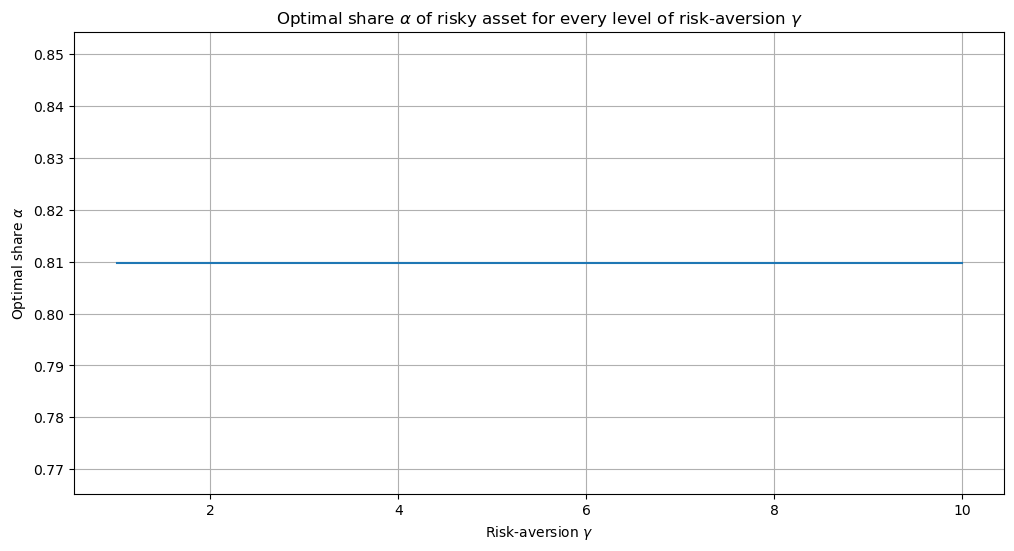

In [32]:
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk-aversion $\gamma$')
plt.xlabel(r'Risk-aversion $\gamma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

_ = plt.plot(gammas, share_opt)

...

### Task 8

In [ ]:
gamma = 4
sigmas = np.linspace(.01, .5, 101)

share_opt = np.empty_like(sigmas)

for i, gamma in enumerate(sigmas):
    s_opt, a_opt, U_max = find_optimum()
    share_opt[i] = a_opt

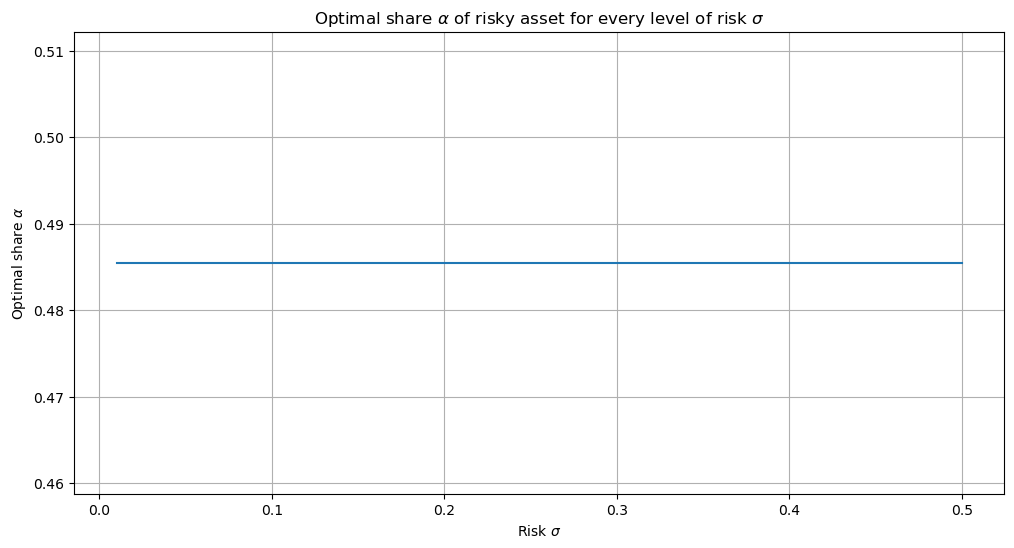

In [332]:
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk $\sigma$')
plt.xlabel(r'Risk $\sigma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

_ = plt.plot(sigmas, share_opt)